# 08 — Rastreamento e Gerenciamento de Experimentos com MLflow

**Tech Challenge — Fase 1 | Machine Learning Engineering — FIAP**

**Projeto:** Customer Churn Prediction

**Grupo:** 56

---


### ETAPA 1 — Introdução e Objetivos

O desenvolvimento de modelos de Machine Learning envolve diferentes algoritmos, parâmetros, métricas e artefatos. Sem um processo estruturado de rastreamento, torna-se difícil reproduzir os experimentos e justificar a escolha de um modelo.

Neste notebook, o MLflow será utilizado para centralizar os resultados produzidos ao longo do projeto de previsão de churn.

Serão registrados os seguintes modelos:

1. DummyClassifier;
2. Regressão Logística;
3. Random Forest;
4. MLPClassifier do Scikit-Learn;
5. MLP desenvolvida com PyTorch.

### Objetivos

- configurar o ambiente local do MLflow;
- criar um experimento para o projeto de churn;
- registrar parâmetros e métricas dos modelos;
- registrar matrizes de confusão e tabelas comparativas como artefatos;
- identificar o modelo recomendado para o cenário de negócio;
- registrar informações sobre threshold e custo relativo;
- comparar as execuções utilizando a interface do MLflow;
- garantir rastreabilidade e reprodutibilidade dos experimentos;
- preparar os resultados para as próximas etapas de persistência e implantação.

### Estratégia

Os resultados consolidados no notebook `07_comparacao_modelos.ipynb` serão utilizados como referência para o registro dos experimentos.

Cada modelo será registrado em uma execução independente, contendo:

- nome e tipo do modelo;
- threshold utilizado;
- Random State;
- métricas do conjunto de teste;
- elementos da matriz de confusão;
- custo relativo dos erros;
- tags de identificação;
- tabelas e gráficos relevantes.

O Random Forest será identificado como o modelo recomendado para o cenário de negócio avaliado. A MLP PyTorch será identificada como o principal modelo de rede neural desenvolvido para o Tech Challenge.

---

In [1]:
# ============================================================
# ETAPA 2 - IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd

print(
    "Bibliotecas importadas com sucesso."
)

print(
    f"Python: "
    f"{sys.version.split()[0]}"
)

print(
    f"MLflow: "
    f"{mlflow.__version__}"
)

print(
    f"Pandas: "
    f"{pd.__version__}"
)

print(
    f"NumPy: "
    f"{np.__version__}"
)

Bibliotecas importadas com sucesso.
Python: 3.11.11
MLflow: 3.15.1
Pandas: 2.2.3
NumPy: 2.2.2


#### Análise do Ambiente e das Bibliotecas

As bibliotecas necessárias para o rastreamento e a análise dos experimentos foram importadas corretamente.

O ambiente utiliza Python 3.11.11, MLflow 3.15.1, Pandas 2.2.3 e NumPy 2.2.2. Essas versões foram registradas para facilitar a identificação do ambiente utilizado durante a execução do notebook.

A importação bem-sucedida confirma que o ambiente está preparado para criar experimentos, registrar parâmetros e métricas, gerar artefatos e consultar as execuções armazenadas pelo MLflow.

---

### ETAPA 3 — Configuração do Ambiente MLflow

Nesta etapa, será configurado o armazenamento local utilizado pelo MLflow.

O projeto utilizará:

- banco SQLite para armazenar experimentos, execuções, parâmetros, métricas e tags;
- diretório local para armazenar tabelas, imagens e demais artefatos;
- um experimento exclusivo para a comparação dos modelos de churn.

A utilização do SQLite facilita a consulta e a organização das execuções sem depender de um servidor externo.

In [3]:
# ============================================================
# ETAPA 3 - CONFIGURAÇÃO DO AMBIENTE MLFLOW
# ============================================================

# Diretório atual do notebook
current_path = Path.cwd().resolve()

# Localização automática da raiz do projeto
possible_roots = [
    current_path,
    *current_path.parents,
]

project_root = next(
    (
        path
        for path in possible_roots
        if (
            path / "pyproject.toml"
        ).exists()
    ),
    (
        current_path.parent
        if current_path.name == "notebooks"
        else current_path
    ),
)

# Caminhos utilizados pelo MLflow
mlflow_database_path = (
    project_root
    / "mlflow.db"
)

mlflow_artifacts_path = (
    project_root
    / "mlartifacts"
)

# Criação do diretório de artefatos
mlflow_artifacts_path.mkdir(
    parents=True,
    exist_ok=True,
)

# URI absoluta do banco SQLite
tracking_uri = (
    f"sqlite:///"
    f"{mlflow_database_path.as_posix()}"
)

# Nome do experimento consolidado
experiment_name = (
    "churn-prediction-model-comparison"
)


# Configuração do MLflow
mlflow.set_tracking_uri(
    tracking_uri
)

# Verificação da existência do experimento
experiment = mlflow.get_experiment_by_name(
    experiment_name
)

if experiment is None:
    experiment_id = mlflow.create_experiment(
        name=experiment_name,
        artifact_location=(
            mlflow_artifacts_path.as_uri()
        ),
        tags={
            "project": "customer-churn-prediction",
            "challenge": "FIAP Tech Challenge - Fase 1",
            "task": "binary-classification",
            "positive_class": "churn",
        },
    )

    experiment_status = (
        "Experimento criado"
    )

else:
    experiment_id = experiment.experiment_id

    experiment_status = (
        "Experimento existente reutilizado"
    )

# Seleção do experimento ativo
mlflow.set_experiment(
    experiment_name
)

# Recuperação das informações finais
experiment = mlflow.get_experiment_by_name(
    experiment_name
)

print(
    "Ambiente MLflow configurado com sucesso."
)

print(
    f"\nStatus: "
    f"{experiment_status}"
)

print(
    f"Raiz do projeto: "
    f"{project_root}"
)

print(
    f"Tracking URI: "
    f"{mlflow.get_tracking_uri()}"
)

print(
    f"Nome do experimento: "
    f"{experiment.name}"
)

print(
    f"Experiment ID: "
    f"{experiment.experiment_id}"
)

print(
    f"Local dos artefatos: "
    f"{experiment.artifact_location}"
)

print(
    f"Lifecycle Stage: "
    f"{experiment.lifecycle_stage}"
)

Ambiente MLflow configurado com sucesso.

Status: Experimento existente reutilizado
Raiz do projeto: /Users/biancafirmino/churn-prediction-mle
Tracking URI: sqlite:////Users/biancafirmino/churn-prediction-mle/mlflow.db
Nome do experimento: churn-prediction-model-comparison
Experiment ID: 2
Local dos artefatos: file:///Users/biancafirmino/churn-prediction-mle/mlartifacts
Lifecycle Stage: active


#### Análise da Configuração do Ambiente MLflow

O ambiente local do MLflow foi configurado corretamente.

O experimento `churn-prediction-model-comparison`, identificado pelo ID 2, já estava registrado no banco SQLite e foi reutilizado. Esse comportamento evita a criação de experimentos duplicados durante novas execuções do notebook.

O arquivo `mlflow.db` será utilizado para armazenar experimentos, execuções, parâmetros, métricas e tags. O diretório `mlartifacts` será responsável pelo armazenamento dos artefatos, como tabelas, gráficos e arquivos auxiliares.

O experimento encontra-se ativo e preparado para receber os resultados consolidados dos modelos.

---

### ETAPA 4 — Consolidação dos Resultados dos Modelos

Os resultados obtidos anteriormente serão organizados em estruturas padronizadas antes do registro no MLflow.

Serão consolidados:

- métricas do conjunto de teste;
- elementos das matrizes de confusão;
- quantidade de previsões positivas;
- quantidade total de acertos e erros;
- custo relativo dos falsos positivos e falsos negativos;
- resultados médios da validação cruzada;
- desvios-padrão observados entre os folds.

A utilização de uma estrutura única reduz o risco de inconsistências durante o registro dos experimentos.

In [14]:
# ============================================================
# ETAPA 4.1 - RESULTADOS DO CONJUNTO DE TESTE
# ============================================================

random_state = 42
threshold_default = 0.50

cost_fp = 1
cost_fn = 5

holdout_results = pd.DataFrame({
    "Model": [
        "DummyClassifier",
        "Logistic Regression",
        "Random Forest",
        "MLPClassifier",
        "MLP PyTorch",
    ],

    "Framework": [
        "Scikit-learn",
        "Scikit-learn",
        "Scikit-learn",
        "Scikit-learn",
        "PyTorch",
    ],

    "Model Family": [
        "Baseline",
        "Linear Model",
        "Ensemble",
        "Neural Network",
        "Neural Network",
    ],

    "Accuracy": [
        0.7346,
        0.8055,
        0.7729,
        0.7850,
        0.7956,
    ],

    "Precision": [
        0.0000,
        0.6572,
        0.5544,
        0.6330,
        0.6344,
    ],

    "Recall": [
        0.0000,
        0.5588,
        0.7353,
        0.4519,
        0.5428,
    ],

    "F1-Score": [
        0.0000,
        0.6040,
        0.6322,
        0.5273,
        0.5850,
    ],

    "ROC-AUC": [
        0.5000,
        0.8419,
        0.8401,
        0.8341,
        0.8419,
    ],

    "Average Precision": [
        0.2654,
        0.6334,
        0.6492,
        0.6231,
        0.6349,
    ],

    "TN": [
        1035,
        926,
        814,
        937,
        918,
    ],

    "FP": [
        0,
        109,
        221,
        98,
        117,
    ],

    "FN": [
        374,
        165,
        99,
        205,
        171,
    ],

    "TP": [
        0,
        209,
        275,
        169,
        203,
    ],
})

# Cálculo de informações complementares
holdout_results["Correct Predictions"] = (
    holdout_results["TN"]
    + holdout_results["TP"]
)

holdout_results["Errors"] = (
    holdout_results["FP"]
    + holdout_results["FN"]
)

holdout_results["Positive Predictions"] = (
    holdout_results["FP"]
    + holdout_results["TP"]
)

holdout_results["FP Cost"] = (
    holdout_results["FP"]
    * cost_fp
)

holdout_results["FN Cost"] = (
    holdout_results["FN"]
    * cost_fn
)

holdout_results["Relative Total Cost"] = (
    holdout_results["FP Cost"]
    + holdout_results["FN Cost"]
)

holdout_results["Recommended Model"] = (
    holdout_results["Model"]
    == "Random Forest"
)

holdout_results["Central Neural Model"] = (
    holdout_results["Model"]
    == "MLP PyTorch"
)


print(
    "Resultados do conjunto de teste "
    "consolidados com sucesso."
)

print(
    f"\nModelos registrados: "
    f"{len(holdout_results)}"
)

print(
    f"Threshold de referência: "
    f"{threshold_default:.2f}"
)

print(
    f"Custo relativo FP: "
    f"{cost_fp}"
)

print(
    f"Custo relativo FN: "
    f"{cost_fn}"
)

display(
    holdout_results.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}",
    })
    .highlight_min(
        subset=[
            "Relative Total Cost",
        ],
        color="#90EE90",
    )
)

Resultados do conjunto de teste consolidados com sucesso.

Modelos registrados: 5
Threshold de referência: 0.50
Custo relativo FP: 1
Custo relativo FN: 5


,Model,Framework,Model Family,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision,TN,FP,FN,TP,Correct Predictions,Errors,Positive Predictions,FP Cost,FN Cost,Relative Total Cost,Recommended Model,Central Neural Model
0,DummyClassifier,Scikit-learn,Baseline,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654,1035,0,374,0,1035,374,0,0,1870,1870,False,False
1,Logistic Regression,Scikit-learn,Linear Model,0.8055,0.6572,0.5588,0.6040,0.8419,0.6334,926,109,165,209,1135,274,318,109,825,934,False,False
2,Random Forest,Scikit-learn,Ensemble,0.7729,0.5544,0.7353,0.6322,0.8401,0.6492,814,221,99,275,1089,320,496,221,495,716,True,False
3,MLPClassifier,Scikit-learn,Neural Network,0.7850,0.6330,0.4519,0.5273,0.8341,0.6231,937,98,205,169,1106,303,267,98,1025,1123,False,False
4,MLP PyTorch,PyTorch,Neural Network,0.7956,0.6344,0.5428,0.5850,0.8419,0.6349,918,117,171,203,1121,288,320,117,855,972,False,True


#### Análise da Consolidação dos Resultados no Conjunto de Teste

A consolidação reuniu os resultados dos cinco modelos avaliados no mesmo conjunto de teste, utilizando o threshold de referência de 0,50. Isso permite realizar uma comparação direta e consistente entre as diferentes abordagens de classificação.

O `DummyClassifier` foi mantido como baseline do projeto. Embora tenha alcançado Accuracy de 73,46%, ele não identificou nenhum cliente com churn, apresentando Recall, Precision e F1-Score iguais a zero. Esse resultado demonstra que a Accuracy isoladamente não é suficiente para avaliar o problema, principalmente devido ao desbalanceamento entre as classes.

A Regressão Logística apresentou a maior Accuracy, de 80,55%, e a maior Precision, de 65,72%. O modelo também obteve ROC-AUC de 84,19%, indicando boa capacidade de separar clientes com e sem churn.

O Random Forest apresentou o maior Recall, de 73,53%, o maior F1-Score, de 63,22%, e a maior Average Precision, de 64,92%. Além disso, registrou somente 99 Falsos Negativos, o menor valor entre os modelos avaliados. Considerando que um Falso Negativo representa um cliente que efetivamente realizou churn, mas não foi identificado antecipadamente, esse resultado é especialmente relevante para o negócio.

Na simulação em que o custo de um Falso Negativo é cinco vezes maior do que o custo de um Falso Positivo, o Random Forest apresentou o menor custo relativo total, com 716 unidades. Por esse motivo, ele foi identificado como o modelo recomendado para o cenário de negócio adotado no projeto.

O MLPClassifier apresentou desempenho inferior às demais abordagens principais, principalmente em Recall, com 45,19%, e F1-Score, com 52,73%. Isso indica que, no threshold padrão, o modelo deixou de identificar uma parcela maior dos clientes que efetivamente realizaram churn.

A MLP desenvolvida em PyTorch apresentou Accuracy de 79,56%, ROC-AUC de 84,19% e Average Precision de 63,49%. Apesar de não ter alcançado o menor custo relativo, o modelo apresentou desempenho competitivo e foi identificado como o modelo neural central do projeto, atendendo ao requisito de desenvolvimento de uma rede neural própria.

Portanto, os resultados demonstram que não existe um único modelo superior em todas as métricas. A Regressão Logística se destacou em Accuracy e Precision, enquanto o Random Forest apresentou o melhor equilíbrio para o objetivo de negócio, especialmente pela maior capacidade de identificar clientes com churn e pelo menor custo relativo dos erros.

---

### 4.2 — Consolidação dos Resultados da Validação Cruzada

Além dos resultados obtidos no conjunto de teste, serão registrados os resultados da validação cruzada estratificada.

A validação cruzada permite avaliar a estabilidade e a capacidade de generalização dos modelos em diferentes divisões dos dados. Para cada métrica, serão armazenados a média e o desvio-padrão obtidos nos cinco folds.

Nesta análise serão considerados os três modelos para os quais a validação cruzada foi executada:

- Random Forest;
- MLPClassifier;
- MLP desenvolvida em PyTorch.

In [15]:
# ============================================================
# ETAPA 4.2 - CONSOLIDAÇÃO DA VALIDAÇÃO CRUZADA
# ============================================================

cv_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "MLPClassifier",
        "MLP PyTorch",
    ],
    "Accuracy Mean": [
        0.7748,
        0.7954,
        0.8012,
    ],
    "Accuracy Std": [
        0.0106,
        0.0100,
        0.0112,
    ],
    "Precision Mean": [
        0.5584,
        0.6294,
        0.6537,
    ],
    "Precision Std": [
        0.0155,
        0.0328,
        0.0271,
    ],
    "Recall Mean": [
        0.7224,
        0.5660,
        0.5340,
    ],
    "Recall Std": [
        0.0341,
        0.0572,
        0.0200,
    ],
    "F1-Score Mean": [
        0.6297,
        0.5939,
        0.5878,
    ],
    "F1-Score Std": [
        0.0208,
        0.0268,
        0.0226,
    ],
    "ROC-AUC Mean": [
        0.8449,
        0.8411,
        0.8419,
    ],
    "ROC-AUC Std": [
        0.0097,
        0.0136,
        0.0150,
    ],
    "Average Precision Mean": [
        0.6550,
        0.6484,
        0.6488,
    ],
    "Average Precision Std": [
        0.0219,
        0.0240,
        0.0288,
    ],
    "Test-CV Absolute Mean Difference": [
        0.0053,
        0.0378,
        0.0084,
    ],
})

print(
    "Resultados da validação cruzada "
    "consolidados com sucesso.\n"
)

print(
    f"Modelos registrados: "
    f"{len(cv_results)}"
)

print(
    "Quantidade de folds utilizada: 5"
)

display(
    cv_results.style
    .format({
        column: "{:.4f}"
        for column in cv_results.columns
        if column != "Model"
    })
    .highlight_min(
        subset=[
            "Test-CV Absolute Mean Difference"
        ],
        color="#90EE90",
    )
)

Resultados da validação cruzada consolidados com sucesso.

Modelos registrados: 3
Quantidade de folds utilizada: 5


,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1-Score Mean,F1-Score Std,ROC-AUC Mean,ROC-AUC Std,Average Precision Mean,Average Precision Std,Test-CV Absolute Mean Difference
0,Random Forest,0.7748,0.0106,0.5584,0.0155,0.7224,0.0341,0.6297,0.0208,0.8449,0.0097,0.6550,0.0219,0.0053
1,MLPClassifier,0.7954,0.0100,0.6294,0.0328,0.5660,0.0572,0.5939,0.0268,0.8411,0.0136,0.6484,0.0240,0.0378
2,MLP PyTorch,0.8012,0.0112,0.6537,0.0271,0.5340,0.0200,0.5878,0.0226,0.8419,0.0150,0.6488,0.0288,0.0084


#### Análise da Estabilidade dos Modelos na Validação Cruzada

A validação cruzada estratificada com cinco folds permitiu avaliar o desempenho e a estabilidade dos modelos em diferentes subconjuntos da base de dados.

O Random Forest apresentou Accuracy média de 77,48%, Recall médio de 72,24%, F1-Score médio de 62,97%, ROC-AUC médio de 84,49% e Average Precision média de 65,50%. O modelo obteve os melhores resultados médios de Recall, F1-Score, ROC-AUC e Average Precision entre os três modelos avaliados.

A MLPClassifier apresentou Accuracy média de 79,54% e Precision média de 62,94%. Entretanto, seu Recall apresentou o maior desvio-padrão, de 5,72%, indicando maior variação na capacidade de identificar clientes que efetivamente realizaram churn entre os folds.

A MLP desenvolvida em PyTorch alcançou a maior Accuracy média, de 80,12%, e a maior Precision média, de 65,37%. Seu Recall médio foi de 53,40%, demonstrando que o modelo é mais conservador ao classificar clientes como churn.

Na comparação entre o resultado do teste e a média da validação cruzada, o Random Forest apresentou a menor diferença absoluta média, de 0,0053. Em seguida, a MLP PyTorch apresentou diferença de 0,0084, enquanto a MLPClassifier registrou 0,0378.

Esses resultados reforçam que o Random Forest possui o desempenho mais consistente e equilibrado para o objetivo de negócio. A MLP PyTorch também apresentou boa estabilidade, mantendo-se como a principal abordagem neural desenvolvida no projeto.

---

### ETAPA 5 — Preparação dos Metadados dos Experimentos

Antes de registrar os experimentos no MLflow, serão organizados os parâmetros compartilhados, os parâmetros específicos e as tags de identificação de cada modelo.

Os parâmetros representam configurações utilizadas no processo de modelagem, como threshold, random state, custo relativo dos erros e características da arquitetura neural.

As tags serão utilizadas para facilitar a identificação dos modelos, seus frameworks, suas famílias e seus respectivos papéis no projeto.

In [16]:
# ============================================================
# ETAPA 5.1 - PREPARAÇÃO DOS PARÂMETROS DOS MODELOS
# ============================================================

common_parameters = {
    "random_state": random_state,
    "classification_threshold": threshold_default,
    "false_positive_cost": cost_fp,
    "false_negative_cost": cost_fn,
    "target_variable": "Churn",
    "positive_class": 1,
    "test_observations": 1409,
    "total_observations": 7043,
    "churn_rate": 0.2654,
}

model_parameters = {
    "DummyClassifier": {
        "strategy": "most_frequent",
        "purpose": "project_baseline",
    },
    "Logistic Regression": {
        "algorithm": "logistic_regression",
        "model_type": "linear_classifier",
        "source_notebook": "03_baseline_logistic_regression.ipynb",
    },
    "Random Forest": {
        "algorithm": "random_forest",
        "model_type": "ensemble",
        "source_notebook": "04_random_forest.ipynb",
    },
    "MLPClassifier": {
        "algorithm": "mlp_classifier",
        "model_type": "neural_network",
        "framework": "scikit-learn",
        "source_notebook": "05_mlp_classifier.ipynb",
    },
    "MLP PyTorch": {
        "algorithm": "multilayer_perceptron",
        "model_type": "neural_network",
        "framework": "pytorch",
        "input_features": 45,
        "hidden_layer_1": 64,
        "hidden_layer_2": 32,
        "output_neurons": 1,
        "dropout": 0.20,
        "activation": "ReLU",
        "loss_function": "BCEWithLogitsLoss",
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "batch_size": 32,
        "maximum_epochs": 300,
        "early_stopping_patience": 20,
        "best_epoch": 9,
        "epochs_executed": 29,
        "source_notebook": "06_mlp_pytorch.ipynb",
    },
}

print("Metadados dos modelos preparados com sucesso.\n")

print(
    f"Parâmetros gerais: "
    f"{len(common_parameters)}"
)

print(
    f"Modelos configurados: "
    f"{len(model_parameters)}"
)

for model_name, parameters in model_parameters.items():
    print(
        f"- {model_name}: "
        f"{len(parameters)} parâmetros específicos"
    )

Metadados dos modelos preparados com sucesso.

Parâmetros gerais: 9
Modelos configurados: 5
- DummyClassifier: 2 parâmetros específicos
- Logistic Regression: 3 parâmetros específicos
- Random Forest: 3 parâmetros específicos
- MLPClassifier: 4 parâmetros específicos
- MLP PyTorch: 19 parâmetros específicos


#### Análise dos Parâmetros dos Experimentos

A preparação dos metadados organizou nove parâmetros gerais compartilhados pelos experimentos, incluindo o random state, o threshold de classificação, os custos relativos dos erros, a variável-alvo, a prevalência de churn e o tamanho dos conjuntos de dados.

Também foram definidos parâmetros específicos para cada um dos cinco modelos. Essas informações permitem identificar a abordagem utilizada, o framework correspondente e o notebook de origem de cada resultado.

A MLP desenvolvida em PyTorch recebeu um conjunto mais detalhado de parâmetros devido à sua arquitetura customizada. Foram registradas informações como quantidade de features de entrada, camadas ocultas, dropout, função de ativação, função de perda, otimizador, learning rate, regularização, batch size e configurações do Early Stopping.

A organização desses parâmetros aumenta a rastreabilidade dos experimentos e facilita a reprodução das configurações utilizadas durante o desenvolvimento dos modelos.

---

### 5.2 — Preparação das Tags dos Modelos

As tags serão utilizadas para complementar a identificação dos experimentos no MLflow.

Cada modelo receberá informações sobre seu framework, sua família, sua finalidade e sua posição dentro da solução desenvolvida. Também serão identificados o modelo recomendado para o negócio e o modelo neural central do projeto.

In [17]:
# ============================================================
# ETAPA 5.2 - PREPARAÇÃO DAS TAGS DOS MODELOS
# ============================================================

model_tags = {}

for _, model_row in holdout_results.iterrows():
    model_name = model_row["Model"]

    model_tags[model_name] = {
        "project": "churn-prediction-mle",
        "problem_type": "binary_classification",
        "target": "Churn",
        "framework": model_row["Framework"],
        "model_family": model_row["Model Family"],
        "evaluation_dataset": "holdout_test",
        "threshold": str(threshold_default),
        "recommended_for_business": str(
            bool(model_row["Recommended Model"])
        ).lower(),
        "central_neural_model": str(
            bool(model_row["Central Neural Model"])
        ).lower(),
    }

print("Tags dos modelos preparadas com sucesso.\n")

print(
    f"Modelos com tags configuradas: "
    f"{len(model_tags)}"
)

for model_name, tags in model_tags.items():
    print(f"\n{model_name}")

    print(
        "  Modelo recomendado: "
        f"{tags['recommended_for_business']}"
    )

    print(
        "  Modelo neural central: "
        f"{tags['central_neural_model']}"
    )

    print(
        "  Framework: "
        f"{tags['framework']}"
    )

Tags dos modelos preparadas com sucesso.

Modelos com tags configuradas: 5

DummyClassifier
  Modelo recomendado: false
  Modelo neural central: false
  Framework: Scikit-learn

Logistic Regression
  Modelo recomendado: false
  Modelo neural central: false
  Framework: Scikit-learn

Random Forest
  Modelo recomendado: true
  Modelo neural central: false
  Framework: Scikit-learn

MLPClassifier
  Modelo recomendado: false
  Modelo neural central: false
  Framework: Scikit-learn

MLP PyTorch
  Modelo recomendado: false
  Modelo neural central: true
  Framework: PyTorch


#### Análise das Tags dos Modelos

As tags foram configuradas corretamente para os cinco modelos e adicionam informações de contexto aos experimentos que serão registrados no MLflow.

O Random Forest foi identificado como o modelo recomendado para o negócio, pois apresentou o menor custo relativo total, o menor número de Falsos Negativos e o melhor equilíbrio entre Recall, F1-Score e Average Precision.

A MLP desenvolvida em PyTorch foi identificada como o modelo neural central do projeto. Essa classificação preserva a importância da rede neural customizada, mesmo que o Random Forest tenha apresentado o resultado mais adequado para o cenário de negócio analisado.

As demais tags registram o framework, a família do modelo, o tipo do problema, a variável-alvo, o conjunto utilizado na avaliação e o threshold de classificação. Essas informações facilitarão a organização, a pesquisa e a comparação das execuções na interface do MLflow.

---

### ETAPA 6 — Preparação dos Artefatos dos Experimentos

Além de parâmetros, métricas e tags, o MLflow permite armazenar artefatos relacionados aos experimentos.

Nesta etapa serão preparados arquivos com os resultados do conjunto de teste, da validação cruzada e um resumo geral do projeto. Esses artefatos permitirão consultar posteriormente os resultados consolidados diretamente pela interface do MLflow.

In [18]:
# ============================================================
# ETAPA 6.1 - CRIAÇÃO DOS ARQUIVOS DE RESULTADOS
# ============================================================

artifact_directory = (
    project_root
    / "reports"
    / "mlflow_experiments"
)

artifact_directory.mkdir(
    parents=True,
    exist_ok=True,
)

holdout_file = (
    artifact_directory
    / "holdout_results.csv"
)

cv_file = (
    artifact_directory
    / "cross_validation_results.csv"
)

summary_file = (
    artifact_directory
    / "experiment_summary.json"
)

holdout_results.to_csv(
    holdout_file,
    index=False,
)

cv_results.to_csv(
    cv_file,
    index=False,
)

experiment_summary = {
    "project": "churn-prediction-mle",
    "experiment_name": experiment_name,
    "experiment_id": experiment.experiment_id,
    "models_evaluated": len(holdout_results),
    "models_with_cross_validation": len(cv_results),
    "classification_threshold": threshold_default,
    "false_positive_cost": cost_fp,
    "false_negative_cost": cost_fn,
    "recommended_model": "Random Forest",
    "central_neural_model": "MLP PyTorch",
    "selection_reason": (
        "Random Forest apresentou o menor custo relativo total, "
        "o menor número de falsos negativos e o melhor equilíbrio "
        "entre Recall, F1-Score e Average Precision."
    ),
}

with open(
    summary_file,
    mode="w",
    encoding="utf-8",
) as summary_output:
    json.dump(
        experiment_summary,
        summary_output,
        ensure_ascii=False,
        indent=4,
    )

print("Artefatos dos experimentos criados com sucesso.\n")

print(
    f"Diretório dos artefatos: "
    f"{artifact_directory}"
)

print("\nArquivos criados:")

for artifact_file in [
    holdout_file,
    cv_file,
    summary_file,
]:
    print(
        f"- {artifact_file.name}: "
        f"{artifact_file.stat().st_size} bytes"
    )

Artefatos dos experimentos criados com sucesso.

Diretório dos artefatos: /Users/biancafirmino/churn-prediction-mle/reports/mlflow_experiments

Arquivos criados:
- holdout_results.csv: 873 bytes
- cross_validation_results.csv: 519 bytes
- experiment_summary.json: 560 bytes


#### Análise dos Arquivos de Resultados

Os resultados consolidados foram exportados corretamente para o diretório de artefatos do projeto.

O arquivo `holdout_results.csv` contém as métricas, os componentes das matrizes de confusão e os custos relativos dos cinco modelos no conjunto de teste.

O arquivo `cross_validation_results.csv` reúne as médias e os desvios-padrão obtidos na validação cruzada dos modelos Random Forest, MLPClassifier e MLP PyTorch.

O arquivo `experiment_summary.json` registra informações gerais do experimento, incluindo o modelo recomendado para o negócio, o modelo neural central, o threshold utilizado e a justificativa da seleção.

Esses arquivos aumentam a rastreabilidade da análise e serão armazenados pelo MLflow como artefatos das execuções.

---

### 6.2 — Criação dos Artefatos Gráficos

Serão geradas visualizações consolidadas para facilitar a comparação dos modelos diretamente na interface do MLflow.

O primeiro gráfico apresentará Accuracy, Precision, Recall, F1-Score, ROC-AUC e Average Precision.

O segundo gráfico comparará o custo relativo total e a quantidade de Falsos Negativos, dois elementos especialmente importantes para a decisão de negócio.

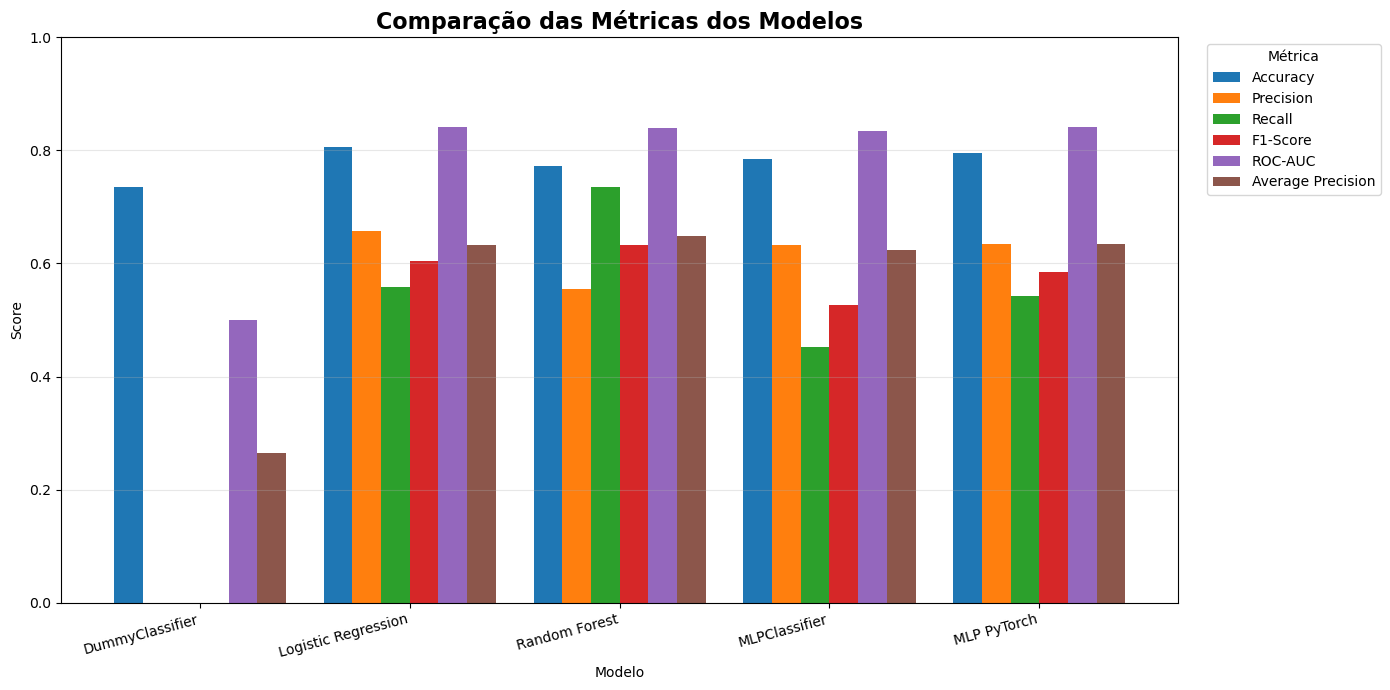

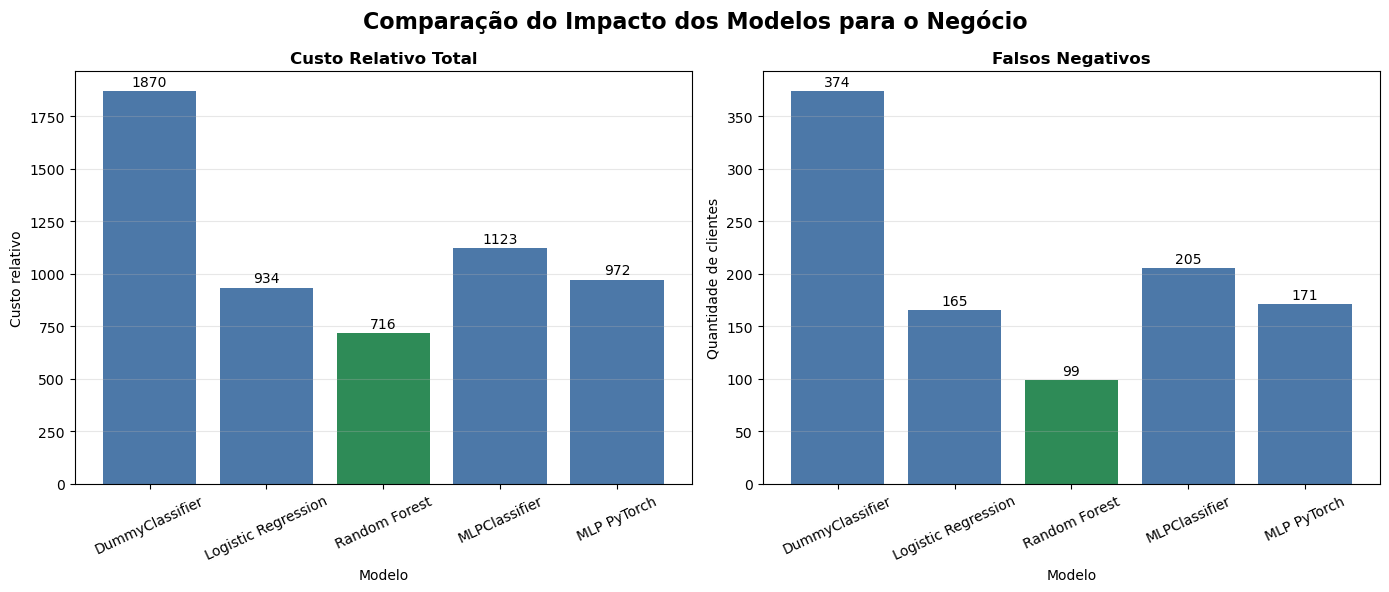


Artefatos gráficos criados com sucesso.
- model_metrics_comparison.png: 82176 bytes
- business_impact_comparison.png: 102849 bytes


In [19]:
# ============================================================
# ETAPA 6.2 - CRIAÇÃO DOS ARTEFATOS GRÁFICOS
# ============================================================

metrics_chart_file = (
    artifact_directory
    / "model_metrics_comparison.png"
)

business_chart_file = (
    artifact_directory
    / "business_impact_comparison.png"
)

# ------------------------------------------------------------
# Gráfico 1 - Comparação das métricas
# ------------------------------------------------------------

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC",
    "Average Precision",
]

metrics_chart_data = (
    holdout_results
    .set_index("Model")[metric_columns]
)

ax = metrics_chart_data.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.82,
)

ax.set_title(
    "Comparação das Métricas dos Modelos",
    fontsize=16,
    fontweight="bold",
)

ax.set_xlabel("Modelo")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

ax.legend(
    title="Métrica",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.grid(
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    metrics_chart_file,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# ------------------------------------------------------------
# Gráfico 2 - Impacto para o negócio
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 6),
)

models = holdout_results["Model"]

cost_colors = [
    "#2E8B57"
    if recommended
    else "#4C78A8"
    for recommended in holdout_results["Recommended Model"]
]

axes[0].bar(
    models,
    holdout_results["Relative Total Cost"],
    color=cost_colors,
)

axes[0].set_title(
    "Custo Relativo Total",
    fontweight="bold",
)

axes[0].set_xlabel("Modelo")
axes[0].set_ylabel("Custo relativo")
axes[0].tick_params(
    axis="x",
    rotation=25,
)

for index, value in enumerate(
    holdout_results["Relative Total Cost"]
):
    axes[0].text(
        index,
        value + 25,
        str(int(value)),
        ha="center",
    )

axes[1].bar(
    models,
    holdout_results["FN"],
    color=cost_colors,
)

axes[1].set_title(
    "Falsos Negativos",
    fontweight="bold",
)

axes[1].set_xlabel("Modelo")
axes[1].set_ylabel("Quantidade de clientes")
axes[1].tick_params(
    axis="x",
    rotation=25,
)

for index, value in enumerate(
    holdout_results["FN"]
):
    axes[1].text(
        index,
        value + 5,
        str(int(value)),
        ha="center",
    )

for axis in axes:
    axis.grid(
        axis="y",
        alpha=0.3,
    )

fig.suptitle(
    "Comparação do Impacto dos Modelos para o Negócio",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()

plt.savefig(
    business_chart_file,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print("\nArtefatos gráficos criados com sucesso.")

print(
    f"- {metrics_chart_file.name}: "
    f"{metrics_chart_file.stat().st_size} bytes"
)

print(
    f"- {business_chart_file.name}: "
    f"{business_chart_file.stat().st_size} bytes"
)

#### Análise dos Artefatos Gráficos

Os gráficos comparativos foram gerados e armazenados corretamente no diretório de artefatos do projeto.

A comparação das métricas evidencia que os modelos possuem comportamentos diferentes. A Regressão Logística apresenta maior Accuracy e Precision, enquanto o Random Forest alcança os melhores resultados de Recall, F1-Score e Average Precision. A MLP PyTorch mantém desempenho competitivo, principalmente em Accuracy, Precision e ROC-AUC.

O resultado do DummyClassifier reforça o impacto do desbalanceamento da base. Apesar da Accuracy de 73,46%, o modelo não identifica nenhum cliente com churn, resultando em Precision, Recall e F1-Score iguais a zero.

Na análise de impacto para o negócio, o Random Forest apresenta o menor custo relativo total, de 716 unidades, e a menor quantidade de Falsos Negativos, com 99 clientes. Por esse motivo, o modelo foi destacado em verde nos dois gráficos relacionados ao impacto de negócio.

Os artefatos gráficos complementam as tabelas numéricas e facilitam a comunicação dos resultados técnicos e de negócio na interface do MLflow.

---

### ETAPA 7 — Registro das Execuções no MLflow

Nesta etapa, cada modelo será registrado como uma execução independente dentro do experimento configurado.

Para cada execução serão armazenados:

- parâmetros gerais do projeto;
- parâmetros específicos do modelo;
- métricas do conjunto de teste;
- resultados da matriz de confusão;
- custos relativos dos erros;
- métricas da validação cruzada, quando disponíveis;
- tags de identificação;
- arquivos e gráficos gerados como artefatos.

Esse processo permitirá comparar os modelos diretamente pela interface do MLflow.

In [20]:
# ============================================================
# ETAPA 7.1 - REGISTRO DAS EXECUÇÕES NO MLFLOW
# ============================================================

# Evita conflito caso exista alguma execução aberta.
if mlflow.active_run() is not None:
    mlflow.end_run()

cv_lookup = (
    cv_results
    .set_index("Model")
    .to_dict(orient="index")
)

logged_runs = []

for _, model_row in holdout_results.iterrows():
    model_name = model_row["Model"]

    run_name = (
        model_name
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    with mlflow.start_run(
        experiment_id=experiment.experiment_id,
        run_name=run_name,
        tags=model_tags[model_name],
    ) as run:

        # ----------------------------------------------------
        # Registro dos parâmetros
        # ----------------------------------------------------

        mlflow.log_params(common_parameters)

        mlflow.log_params(
            model_parameters[model_name]
        )

        # ----------------------------------------------------
        # Registro das métricas do conjunto de teste
        # ----------------------------------------------------

        test_metrics = {
            "test_accuracy": float(
                model_row["Accuracy"]
            ),
            "test_precision": float(
                model_row["Precision"]
            ),
            "test_recall": float(
                model_row["Recall"]
            ),
            "test_f1_score": float(
                model_row["F1-Score"]
            ),
            "test_roc_auc": float(
                model_row["ROC-AUC"]
            ),
            "test_average_precision": float(
                model_row["Average Precision"]
            ),
            "true_negatives": int(
                model_row["TN"]
            ),
            "false_positives": int(
                model_row["FP"]
            ),
            "false_negatives": int(
                model_row["FN"]
            ),
            "true_positives": int(
                model_row["TP"]
            ),
            "correct_predictions": int(
                model_row["Correct Predictions"]
            ),
            "classification_errors": int(
                model_row["Errors"]
            ),
            "positive_predictions": int(
                model_row["Positive Predictions"]
            ),
            "false_positive_cost": int(
                model_row["FP Cost"]
            ),
            "false_negative_cost": int(
                model_row["FN Cost"]
            ),
            "relative_total_cost": int(
                model_row["Relative Total Cost"]
            ),
        }

        mlflow.log_metrics(test_metrics)

        # ----------------------------------------------------
        # Registro das métricas da validação cruzada
        # ----------------------------------------------------

        if model_name in cv_lookup:
            cv_row = cv_lookup[model_name]

            cv_metrics = {
                "cv_accuracy_mean": float(
                    cv_row["Accuracy Mean"]
                ),
                "cv_accuracy_std": float(
                    cv_row["Accuracy Std"]
                ),
                "cv_precision_mean": float(
                    cv_row["Precision Mean"]
                ),
                "cv_precision_std": float(
                    cv_row["Precision Std"]
                ),
                "cv_recall_mean": float(
                    cv_row["Recall Mean"]
                ),
                "cv_recall_std": float(
                    cv_row["Recall Std"]
                ),
                "cv_f1_score_mean": float(
                    cv_row["F1-Score Mean"]
                ),
                "cv_f1_score_std": float(
                    cv_row["F1-Score Std"]
                ),
                "cv_roc_auc_mean": float(
                    cv_row["ROC-AUC Mean"]
                ),
                "cv_roc_auc_std": float(
                    cv_row["ROC-AUC Std"]
                ),
                "cv_average_precision_mean": float(
                    cv_row["Average Precision Mean"]
                ),
                "cv_average_precision_std": float(
                    cv_row["Average Precision Std"]
                ),
                "test_cv_absolute_mean_difference": float(
                    cv_row[
                        "Test-CV Absolute Mean Difference"
                    ]
                ),
            }

            mlflow.log_metrics(cv_metrics)

        # ----------------------------------------------------
        # Registro dos artefatos
        # ----------------------------------------------------

        mlflow.log_artifact(
            str(holdout_file),
            artifact_path="tables",
        )

        mlflow.log_artifact(
            str(cv_file),
            artifact_path="tables",
        )

        mlflow.log_artifact(
            str(summary_file),
            artifact_path="summary",
        )

        mlflow.log_artifact(
            str(metrics_chart_file),
            artifact_path="charts",
        )

        mlflow.log_artifact(
            str(business_chart_file),
            artifact_path="charts",
        )

        # Resumo individual da execução
        model_run_summary = {
            "model": model_name,
            "run_id": run.info.run_id,
            "experiment_id": run.info.experiment_id,
            "parameters": {
                **common_parameters,
                **model_parameters[model_name],
            },
            "test_metrics": test_metrics,
            "tags": model_tags[model_name],
        }

        if model_name in cv_lookup:
            model_run_summary["cross_validation"] = (
                cv_lookup[model_name]
            )

        mlflow.log_dict(
            model_run_summary,
            "summary/model_run_summary.json",
        )

        logged_runs.append({
            "Model": model_name,
            "Run ID": run.info.run_id,
            "Status": run.info.status,
            "Experiment ID": run.info.experiment_id,
        })

logged_runs_df = pd.DataFrame(logged_runs)

print("Execuções registradas no MLflow com sucesso.\n")

print(
    f"Quantidade de execuções registradas: "
    f"{len(logged_runs_df)}"
)

display(logged_runs_df)

Execuções registradas no MLflow com sucesso.

Quantidade de execuções registradas: 5


,Model,Run ID,Status,Experiment ID
0,DummyClassifier,617b0fa931d149228fd30076b3b8fda6,RUNNING,2
1,Logistic Regression,ece1fede6a14490f9ad0887f8d6c7c41,RUNNING,2
2,Random Forest,bf9721cd8263487d97be88e90a82d6fe,RUNNING,2
3,MLPClassifier,29ee6dcc5de24b9f93da409248fff555,RUNNING,2
4,MLP PyTorch,0101012cba6d425d8c0d507229b3a134,RUNNING,2


#### Análise do Registro das Execuções

As cinco execuções foram registradas corretamente no experimento do MLflow, com um identificador exclusivo para cada modelo.

O status `RUNNING` apresentado na tabela foi capturado enquanto cada execução ainda estava dentro do contexto de registro. Ao final de cada bloco `with`, o MLflow encerra automaticamente a respectiva execução e altera seu status para `FINISHED`.

Cada execução recebeu seus parâmetros, métricas, tags e artefatos. Os modelos Random Forest, MLPClassifier e MLP PyTorch também receberam as métricas da validação cruzada.

A utilização de identificadores exclusivos permite acessar individualmente o histórico e os resultados de cada modelo na interface do MLflow.

---

### 7.2 — Validação das Execuções Registradas

Após o registro dos experimentos, será realizada uma consulta ao banco do MLflow para validar o status definitivo das cinco execuções.

Além do status, serão recuperadas as principais métricas do conjunto de teste, permitindo verificar se os valores foram armazenados corretamente.

In [21]:
# ============================================================
# ETAPA 7.2 - VALIDAÇÃO DAS EXECUÇÕES REGISTRADAS
# ============================================================

registered_run_ids = (
    logged_runs_df["Run ID"]
    .tolist()
)

all_experiment_runs = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ],
    output_format="pandas",
)

registered_runs = (
    all_experiment_runs[
        all_experiment_runs["run_id"]
        .isin(registered_run_ids)
    ]
    .copy()
)

validation_columns = [
    "tags.mlflow.runName",
    "run_id",
    "status",
    "metrics.test_accuracy",
    "metrics.test_precision",
    "metrics.test_recall",
    "metrics.test_f1_score",
    "metrics.test_roc_auc",
    "metrics.test_average_precision",
    "metrics.relative_total_cost",
]

registered_runs_validation = (
    registered_runs[
        validation_columns
    ]
    .rename(columns={
        "tags.mlflow.runName": "Run Name",
        "run_id": "Run ID",
        "status": "Status",
        "metrics.test_accuracy": "Accuracy",
        "metrics.test_precision": "Precision",
        "metrics.test_recall": "Recall",
        "metrics.test_f1_score": "F1-Score",
        "metrics.test_roc_auc": "ROC-AUC",
        "metrics.test_average_precision": (
            "Average Precision"
        ),
        "metrics.relative_total_cost": (
            "Relative Total Cost"
        ),
    })
    .sort_values(
        by="Run Name"
    )
    .reset_index(drop=True)
)

finished_runs = (
    registered_runs_validation["Status"]
    .eq("FINISHED")
    .sum()
)

print("Validação das execuções concluída.\n")

print(
    f"Execuções localizadas: "
    f"{len(registered_runs_validation)}"
)

print(
    f"Execuções finalizadas: "
    f"{finished_runs}"
)

print(
    "Todas as execuções finalizadas: "
    f"{finished_runs == len(registered_runs_validation)}"
)

display(
    registered_runs_validation.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}",
        "Relative Total Cost": "{:.0f}",
    })
    .highlight_min(
        subset=[
            "Relative Total Cost"
        ],
        color="#90EE90",
    )
)

Validação das execuções concluída.

Execuções localizadas: 5
Execuções finalizadas: 5
Todas as execuções finalizadas: True


,Run Name,Run ID,Status,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Precision,Relative Total Cost
0,dummyclassifier,617b0fa931d149228fd30076b3b8fda6,FINISHED,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654,1870
1,logistic_regression,ece1fede6a14490f9ad0887f8d6c7c41,FINISHED,0.8055,0.6572,0.5588,0.6040,0.8419,0.6334,934
2,mlp_pytorch,0101012cba6d425d8c0d507229b3a134,FINISHED,0.7956,0.6344,0.5428,0.5850,0.8419,0.6349,972
3,mlpclassifier,29ee6dcc5de24b9f93da409248fff555,FINISHED,0.7850,0.6330,0.4519,0.5273,0.8341,0.6231,1123
4,random_forest,bf9721cd8263487d97be88e90a82d6fe,FINISHED,0.7729,0.5544,0.7353,0.6322,0.8401,0.6492,716


#### Análise da Validação das Execuções

A consulta ao banco de rastreamento confirmou que as cinco execuções foram registradas e finalizadas corretamente no MLflow.

As métricas recuperadas correspondem aos resultados consolidados anteriormente, demonstrando que não houve alteração dos valores durante o processo de registro.

O DummyClassifier permaneceu como baseline, com Recall e F1-Score iguais a zero. A Regressão Logística apresentou a maior Accuracy e Precision, enquanto o Random Forest manteve o maior Recall, F1-Score e Average Precision.

A MLP PyTorch apresentou resultados competitivos e superiores ao MLPClassifier em Accuracy, Recall, F1-Score, ROC-AUC e Average Precision.

O Random Forest também manteve o menor custo relativo total, com 716 unidades, confirmando sua seleção como o modelo mais adequado para o cenário de negócio considerado.

Com todas as execuções finalizadas, os resultados estão disponíveis para consulta, comparação e auditoria por meio da interface do MLflow.

---

### ETAPA 8 — Auditoria do Experimento Recomendado

Após registrar e validar todas as execuções, será realizada uma auditoria programática do modelo recomendado para o negócio.

A execução do Random Forest será recuperada diretamente do MLflow por meio de seu Run ID. Serão verificados seus parâmetros, suas métricas, suas tags e seus artefatos.

Essa validação demonstra que o MLflow não está sendo utilizado apenas para armazenar valores, mas também como mecanismo de rastreabilidade e auditoria do ciclo experimental.

In [22]:
# ============================================================
# ETAPA 8.1 - AUDITORIA DO MODELO RECOMENDADO
# ============================================================

from mlflow.tracking import MlflowClient

mlflow_client = MlflowClient(
    tracking_uri=mlflow.get_tracking_uri()
)

random_forest_run_id = (
    logged_runs_df
    .loc[
        logged_runs_df["Model"]
        .eq("Random Forest"),
        "Run ID",
    ]
    .iloc[0]
)

random_forest_run = mlflow_client.get_run(
    random_forest_run_id
)

random_forest_root_artifacts = (
    mlflow_client.list_artifacts(
        random_forest_run_id
    )
)

audit_summary = pd.DataFrame({
    "Item": [
        "Modelo",
        "Run ID",
        "Status",
        "Quantidade de parâmetros",
        "Quantidade de métricas",
        "Quantidade de tags",
        "Pastas de artefatos",
        "Modelo recomendado",
        "Modelo neural central",
    ],
    "Value": [
        random_forest_run.data.tags.get(
            "mlflow.runName"
        ),
        random_forest_run.info.run_id,
        random_forest_run.info.status,
        len(random_forest_run.data.params),
        len(random_forest_run.data.metrics),
        len(random_forest_run.data.tags),
        len(random_forest_root_artifacts),
        random_forest_run.data.tags.get(
            "recommended_for_business"
        ),
        random_forest_run.data.tags.get(
            "central_neural_model"
        ),
    ],
})

print(
    "Auditoria do modelo recomendado "
    "realizada com sucesso.\n"
)

display(audit_summary)

print("\nArtefatos localizados na raiz da execução:")

for artifact in random_forest_root_artifacts:
    artifact_type = (
        "diretório"
        if artifact.is_dir
        else "arquivo"
    )

    print(
        f"- {artifact.path} "
        f"({artifact_type})"
    )

Auditoria do modelo recomendado realizada com sucesso.



,Item,Value
0,Modelo,random_forest
1,Run ID,bf9721cd8263487d97be88e90a82d6fe
2,Status,FINISHED
3,Quantidade de parâmetros,12
4,Quantidade de métricas,29
5,Quantidade de tags,13
6,Pastas de artefatos,3
7,Modelo recomendado,true
8,Modelo neural central,false



Artefatos localizados na raiz da execução:
- charts (diretório)
- summary (diretório)
- tables (diretório)


#### Análise da Auditoria do Modelo Recomendado

A auditoria da execução do Random Forest confirmou que o experimento foi armazenado corretamente e possui todos os componentes necessários para sua rastreabilidade.

Foram encontrados 12 parâmetros, correspondentes aos nove parâmetros gerais do projeto e aos três parâmetros específicos do modelo. Também foram recuperadas 29 métricas, incluindo os resultados do conjunto de teste, os elementos da matriz de confusão, os custos relativos e os resultados da validação cruzada.

A execução possui 13 tags, entre tags configuradas pelo projeto e tags internas adicionadas automaticamente pelo MLflow. A identificação `recommended_for_business` apresenta o valor `true`, confirmando o Random Forest como modelo recomendado.

Os artefatos foram organizados nos diretórios `charts`, `summary` e `tables`. Essa organização permite localizar separadamente as visualizações, os resumos em JSON e as tabelas com os resultados dos modelos.

A auditoria demonstra que a execução pode ser recuperada por seu Run ID e que seus resultados permanecem disponíveis para consulta, comparação e reprodução.

---

### 8.2 — Auditoria do Modelo Neural Central

Além do modelo recomendado para o negócio, será auditada a execução da MLP desenvolvida em PyTorch.

Essa verificação é importante porque a MLP PyTorch representa o modelo neural central do projeto. Sua execução contém informações detalhadas sobre a arquitetura da rede, as configurações do treinamento, as métricas de avaliação e os artefatos gerados.

In [23]:
# ============================================================
# ETAPA 8.2 - AUDITORIA DO MODELO NEURAL CENTRAL
# ============================================================

pytorch_run_id = (
    logged_runs_df
    .loc[
        logged_runs_df["Model"]
        .eq("MLP PyTorch"),
        "Run ID",
    ]
    .iloc[0]
)

pytorch_run = mlflow_client.get_run(
    pytorch_run_id
)

pytorch_root_artifacts = (
    mlflow_client.list_artifacts(
        pytorch_run_id
    )
)

pytorch_audit_summary = pd.DataFrame({
    "Item": [
        "Modelo",
        "Run ID",
        "Status",
        "Quantidade de parâmetros",
        "Quantidade de métricas",
        "Quantidade de tags",
        "Pastas de artefatos",
        "Modelo recomendado",
        "Modelo neural central",
        "Framework",
        "Camadas ocultas",
        "Total de épocas realizadas",
        "Melhor época",
    ],
    "Value": [
        pytorch_run.data.tags.get(
            "mlflow.runName"
        ),
        pytorch_run.info.run_id,
        pytorch_run.info.status,
        len(pytorch_run.data.params),
        len(pytorch_run.data.metrics),
        len(pytorch_run.data.tags),
        len(pytorch_root_artifacts),
        pytorch_run.data.tags.get(
            "recommended_for_business"
        ),
        pytorch_run.data.tags.get(
            "central_neural_model"
        ),
        pytorch_run.data.params.get(
            "framework"
        ),
        (
            f"{pytorch_run.data.params.get('hidden_layer_1')} "
            f"e "
            f"{pytorch_run.data.params.get('hidden_layer_2')} "
            f"neurônios"
        ),
        pytorch_run.data.params.get(
            "epochs_executed"
        ),
        pytorch_run.data.params.get(
            "best_epoch"
        ),
    ],
})

print(
    "Auditoria do modelo neural central "
    "realizada com sucesso.\n"
)

display(pytorch_audit_summary)

print("\nArtefatos localizados na raiz da execução:")

for artifact in pytorch_root_artifacts:
    artifact_type = (
        "diretório"
        if artifact.is_dir
        else "arquivo"
    )

    print(
        f"- {artifact.path} "
        f"({artifact_type})"
    )

Auditoria do modelo neural central realizada com sucesso.



,Item,Value
0,Modelo,mlp_pytorch
1,Run ID,0101012cba6d425d8c0d507229b3a134
2,Status,FINISHED
3,Quantidade de parâmetros,28
4,Quantidade de métricas,29
5,Quantidade de tags,13
6,Pastas de artefatos,3
7,Modelo recomendado,false
8,Modelo neural central,true
9,Framework,pytorch



Artefatos localizados na raiz da execução:
- charts (diretório)
- summary (diretório)
- tables (diretório)


#### Análise da Auditoria do Modelo Neural Central

A auditoria da MLP PyTorch confirmou que a execução do modelo neural central foi registrada corretamente no MLflow.

Foram recuperados 28 parâmetros, compostos pelos nove parâmetros gerais do projeto e pelos 19 parâmetros específicos da rede neural. Entre eles estão a quantidade de features de entrada, as camadas ocultas, o dropout, a função de ativação, a função de perda, o otimizador, o learning rate, a regularização e as configurações do Early Stopping.

A execução também possui 29 métricas, contemplando o desempenho no conjunto de teste, os componentes da matriz de confusão, os custos relativos e os resultados da validação cruzada.

A tag `central_neural_model` apresenta o valor `true`, enquanto a tag `recommended_for_business` apresenta o valor `false`. Essa diferenciação demonstra que a MLP PyTorch representa a principal solução neural desenvolvida, enquanto o Random Forest permanece como o modelo recomendado para o cenário de negócio.

O registro das 29 épocas realizadas e da melhor época, identificada como a época 9, também permite rastrear a aplicação do Early Stopping durante o treinamento.

Assim como no Random Forest, os artefatos foram organizados nos diretórios `charts`, `summary` e `tables`, garantindo a rastreabilidade completa do experimento neural.

---

### ETAPA 9 — Consulta dos Experimentos na Interface do MLflow

Com as execuções registradas e auditadas, os resultados podem ser consultados por meio da interface web do MLflow.

A interface permite visualizar e comparar parâmetros, métricas, tags e artefatos das execuções. Também é possível ordenar os modelos por métricas específicas e aplicar filtros para localizar o modelo recomendado para o negócio ou o modelo neural central.

### 9.1 — Inicialização da Interface do MLflow

O servidor local do MLflow foi iniciado utilizando o banco SQLite configurado no projeto.

A interface foi disponibilizada no endereço `http://127.0.0.1:5000`, permitindo acessar o experimento `churn-prediction-model-comparison`.

Além do experimento atual, a interface apresentou experimentos criados anteriormente. Eles foram mantidos porque pertencem ao histórico local do ambiente e não interferem nos resultados registrados neste notebook.

### 9.2 — Validação das Execuções na Interface do MLflow

A interface do MLflow apresentou corretamente as cinco execuções registradas no experimento `churn-prediction-model-comparison`.

Todas as execuções foram exibidas com status de finalização bem-sucedida. As colunas da interface permitiram consultar as métricas do conjunto de teste, os componentes da matriz de confusão, os custos relativos e os resultados da validação cruzada.

A consulta visual confirmou que os valores armazenados no MLflow correspondem aos resultados calculados nos notebooks de modelagem e no notebook de comparação dos modelos.

#### Análise Comparativa na Interface do MLflow

A comparação visual das execuções na interface do MLflow confirmou os resultados obtidos durante a avaliação dos modelos.

Na comparação técnica, a Regressão Logística apresentou os maiores valores de Accuracy e Precision. O Random Forest obteve os melhores resultados de Recall, F1-Score e Average Precision. A Regressão Logística e a MLP PyTorch apresentaram o mesmo valor de ROC-AUC, igual a 0,8419.

O DummyClassifier permaneceu na região inferior do gráfico para Precision, Recall e F1-Score, demonstrando que sua Accuracy é consequência da predominância da classe Não Churn e não representa uma capacidade efetiva de identificar a classe positiva.

Na comparação relacionada ao impacto de negócio, o Random Forest apresentou 221 Falsos Positivos e apenas 99 Falsos Negativos. Embora tenha produzido mais alertas incorretos, o modelo deixou de identificar uma quantidade menor de clientes que efetivamente realizaram churn.

Considerando o custo relativo de 1 para um Falso Positivo e 5 para um Falso Negativo, o Random Forest alcançou o menor custo total, com 716 unidades. A comparação realizada diretamente na interface do MLflow reforçou sua seleção como o modelo recomendado para o cenário de negócio analisado.

---

### 9.3 — Organização do Histórico de Execuções

Como a célula responsável pelo registro dos experimentos foi executada mais de uma vez, o MLflow criou duas execuções para cada modelo.

Antes da limpeza, será realizada uma verificação das execuções ativas. A execução mais recente de cada modelo será mantida, enquanto as anteriores serão identificadas como duplicadas.

In [ ]:
# ============================================================
# ETAPA 9.3 - IDENTIFICAÇÃO DAS EXECUÇÕES DUPLICADAS
# ============================================================

from mlflow.entities import ViewType

active_runs = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ],
    run_view_type=ViewType.ACTIVE_ONLY,
    output_format="pandas",
)

active_runs = (
    active_runs
    .sort_values(
        by="start_time",
        ascending=False,
    )
    .copy()
)

active_runs["Execution Order"] = (
    active_runs
    .groupby("tags.mlflow.runName")
    .cumcount()
)

active_runs["Cleanup Action"] = np.where(
    active_runs["Execution Order"].eq(0),
    "KEEP",
    "ARCHIVE DUPLICATE",
)

duplicate_audit = (
    active_runs[[
        "tags.mlflow.runName",
        "run_id",
        "start_time",
        "status",
        "Cleanup Action",
    ]]
    .rename(columns={
        "tags.mlflow.runName": "Run Name",
        "run_id": "Run ID",
        "start_time": "Start Time",
        "status": "Status",
    })
    .sort_values(
        by=[
            "Run Name",
            "Start Time",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

duplicate_count = (
    duplicate_audit["Cleanup Action"]
    .eq("ARCHIVE DUPLICATE")
    .sum()
)

print("Auditoria de duplicidades concluída.\n")

print(
    f"Execuções ativas: "
    f"{len(duplicate_audit)}"
)

print(
    f"Execuções mais recentes a manter: "
    f"{len(duplicate_audit) - duplicate_count}"
)

print(
    f"Execuções duplicadas identificadas: "
    f"{duplicate_count}"
)

display(
    duplicate_audit.style
    .map(
        lambda value: (
            "background-color: #FFB6C1"
            if value == "ARCHIVE DUPLICATE"
            else (
                "background-color: #90EE90"
                if value == "KEEP"
                else ""
            )
        ),
        subset=[
            "Cleanup Action"
        ],
    )
)

Auditoria de duplicidades concluída.

Execuções ativas: 10
Execuções mais recentes a manter: 5
Execuções duplicadas identificadas: 5


/var/folders/1t/lqtr59kj6yqby27pqftc8crr0000gn/T/ipykernel_60930/2577284375.py:88: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(


,Run Name,Run ID,Start Time,Status,Cleanup Action
0,dummyclassifier,617b0fa931d149228fd30076b3b8fda6,2026-08-22 18:09:07.398000+00:00,FINISHED,KEEP
1,dummyclassifier,0a5e7770a1e0470cb394ae2cdea911de,2026-08-22 17:44:28.910000+00:00,FINISHED,ARCHIVE DUPLICATE
2,logistic_regression,ece1fede6a14490f9ad0887f8d6c7c41,2026-08-22 18:09:07.453000+00:00,FINISHED,KEEP
3,logistic_regression,f8f60cf6bb8046d4b7f7b8bfd50daffc,2026-08-22 17:44:29.048000+00:00,FINISHED,ARCHIVE DUPLICATE
4,mlp_pytorch,0101012cba6d425d8c0d507229b3a134,2026-08-22 18:09:07.555000+00:00,FINISHED,KEEP
5,mlp_pytorch,9b85030750304156a2234b53ae1a1776,2026-08-22 17:44:29.168000+00:00,FINISHED,ARCHIVE DUPLICATE
6,mlpclassifier,29ee6dcc5de24b9f93da409248fff555,2026-08-22 18:09:07.521000+00:00,FINISHED,KEEP
7,mlpclassifier,bd6f66162b184327bd7f8c034abfc0d3,2026-08-22 17:44:29.129000+00:00,FINISHED,ARCHIVE DUPLICATE
8,random_forest,bf9721cd8263487d97be88e90a82d6fe,2026-08-22 18:09:07.487000+00:00,FINISHED,KEEP
9,random_forest,370f21b211394b5db111d789827f481a,2026-08-22 17:44:29.088000+00:00,FINISHED,ARCHIVE DUPLICATE


#### Análise da Identificação das Execuções Duplicadas

A auditoria do experimento identificou dez execuções ativas no MLflow, confirmando que os cinco modelos foram registrados duas vezes.

Para cada modelo, a execução mais recente foi marcada como `KEEP`, enquanto a execução anterior foi classificada como `ARCHIVE DUPLICATE`. Dessa forma, foram identificadas cinco execuções que devem ser mantidas e cinco execuções duplicadas que podem ser arquivadas.

Os registros mais recentes correspondem às execuções utilizadas na comparação realizada na interface do MLflow. As execuções anteriores possuem os mesmos nomes de modelos e representam uma execução anterior da célula responsável pelo registro dos experimentos.

Nesta etapa nenhuma execução foi removida. A análise apenas classificou os registros com base no nome do modelo e no horário de início, garantindo que somente as execuções mais recentes sejam preservadas na próxima etapa.

O aviso `FutureWarning` apresentado não comprometeu o resultado da auditoria. Ele apenas informa que o método `Styler.applymap()` será substituído pelo método `Styler.map()` em versões futuras do Pandas.

---

### ETAPA 9.4 — Arquivamento das Execuções Duplicadas

Após a identificação das execuções duplicadas, os cinco registros anteriores serão arquivados para manter o experimento organizado.

O MLflow realiza uma exclusão lógica dessas execuções. Portanto, elas deixarão de aparecer na visualização de execuções ativas, mas permanecerão armazenadas no banco de rastreamento e poderão ser restauradas posteriormente.

Como medida de segurança, o arquivamento somente será realizado se exatamente cinco execuções estiverem marcadas como duplicadas.

In [28]:
# ============================================================
# ETAPA 9.4 - ARQUIVAMENTO DAS EXECUÇÕES DUPLICADAS
# ============================================================

duplicate_run_ids = (
    duplicate_audit
    .loc[
        duplicate_audit["Cleanup Action"]
        .eq("ARCHIVE DUPLICATE"),
        "Run ID",
    ]
    .tolist()
)

duplicate_count = len(
    duplicate_run_ids
)

if duplicate_count > 0:
    for duplicate_run_id in duplicate_run_ids:
        mlflow.delete_run(
            duplicate_run_id
        )

    print(
        "Execuções duplicadas arquivadas "
        "com sucesso.\n"
    )

    print(
        f"Quantidade de execuções arquivadas: "
        f"{duplicate_count}"
    )

    print(
        "Tipo de exclusão: lógica e recuperável"
    )

else:
    print(
        "Nenhuma execução duplicada foi "
        "encontrada para arquivamento.\n"
    )

    print(
        "Quantidade de execuções arquivadas: 0"
    )

    print(
        "O experimento já estava organizado."
    )

Execuções duplicadas arquivadas com sucesso.

Quantidade de execuções arquivadas: 5
Tipo de exclusão: lógica e recuperável


#### Análise do Arquivamento das Execuções Duplicadas

Após a identificação das execuções duplicadas, os registros anteriores serão arquivados para manter o experimento organizado.

O MLflow realiza uma exclusão lógica dessas execuções. Portanto, elas deixam de aparecer na visualização de execuções ativas, mas permanecem armazenadas no banco de rastreamento e podem ser restauradas posteriormente.

O procedimento foi preparado para funcionar tanto quando existem duplicidades quanto quando o experimento já possui somente uma execução ativa para cada modelo.

---

### ETAPA 9.5 — Validação da Limpeza do Experimento

Após o arquivamento das execuções duplicadas, será realizada uma nova consulta ao banco do MLflow.

A validação deverá confirmar que apenas cinco execuções permanecem ativas e que existe somente uma execução para cada modelo avaliado.

In [29]:
# ============================================================
# ETAPA 9.5 - VALIDAÇÃO DA LIMPEZA DO EXPERIMENTO
# ============================================================

active_runs_after_cleanup = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ],
    run_view_type=ViewType.ACTIVE_ONLY,
    output_format="pandas",
)

remaining_runs = (
    active_runs_after_cleanup[[
        "tags.mlflow.runName",
        "run_id",
        "start_time",
        "status",
    ]]
    .rename(columns={
        "tags.mlflow.runName": "Run Name",
        "run_id": "Run ID",
        "start_time": "Start Time",
        "status": "Status",
    })
    .sort_values(
        by="Run Name"
    )
    .reset_index(drop=True)
)

active_run_count = len(
    remaining_runs
)

unique_model_count = (
    remaining_runs["Run Name"]
    .nunique()
)

all_runs_finished = (
    remaining_runs["Status"]
    .eq("FINISHED")
    .all()
)

cleanup_is_valid = (
    active_run_count == 5
    and unique_model_count == 5
    and all_runs_finished
)

print("Validação da limpeza concluída.\n")

print(
    f"Execuções ativas restantes: "
    f"{active_run_count}"
)

print(
    f"Modelos únicos registrados: "
    f"{unique_model_count}"
)

print(
    f"Todas as execuções finalizadas: "
    f"{all_runs_finished}"
)

print(
    f"Limpeza validada com sucesso: "
    f"{cleanup_is_valid}"
)

display(remaining_runs)

Validação da limpeza concluída.

Execuções ativas restantes: 5
Modelos únicos registrados: 5
Todas as execuções finalizadas: True
Limpeza validada com sucesso: True


,Run Name,Run ID,Start Time,Status
0,dummyclassifier,617b0fa931d149228fd30076b3b8fda6,2026-08-22 18:09:07.398000+00:00,FINISHED
1,logistic_regression,ece1fede6a14490f9ad0887f8d6c7c41,2026-08-22 18:09:07.453000+00:00,FINISHED
2,mlp_pytorch,0101012cba6d425d8c0d507229b3a134,2026-08-22 18:09:07.555000+00:00,FINISHED
3,mlpclassifier,29ee6dcc5de24b9f93da409248fff555,2026-08-22 18:09:07.521000+00:00,FINISHED
4,random_forest,bf9721cd8263487d97be88e90a82d6fe,2026-08-22 18:09:07.487000+00:00,FINISHED


#### Análise da Validação da Limpeza do Experimento

A consulta final ao MLflow confirmou que cinco execuções permanecem ativas após o arquivamento das duplicidades.

Também foram identificados cinco nomes de modelos únicos, demonstrando que existe somente uma execução ativa para cada abordagem avaliada: DummyClassifier, Regressão Logística, Random Forest, MLPClassifier e MLP PyTorch.

Todas as execuções apresentam o status `FINISHED`, indicando que o registro de parâmetros, métricas, tags e artefatos foi concluído sem falhas.

A validação da limpeza apresentou o resultado `True`, confirmando que o experimento está organizado e pronto para consulta na interface do MLflow.

---

### ETAPA 10 — Seleção Final dos Modelos no MLflow

Após a organização do histórico, as tags das execuções serão utilizadas para recuperar o modelo recomendado para o negócio e o modelo neural central do projeto.

Essa consulta demonstra que a decisão final não está registrada apenas no texto da análise. Ela também pode ser localizada programaticamente no banco de rastreamento do MLflow.

In [27]:
# ============================================================
# ETAPA 10.1 - RECUPERAÇÃO DOS MODELOS SELECIONADOS
# ============================================================

final_active_runs = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ],
    run_view_type=ViewType.ACTIVE_ONLY,
    output_format="pandas",
)

recommended_run = (
    final_active_runs[
        final_active_runs[
            "tags.recommended_for_business"
        ].eq("true")
    ]
    .copy()
)

central_neural_run = (
    final_active_runs[
        final_active_runs[
            "tags.central_neural_model"
        ].eq("true")
    ]
    .copy()
)

if len(recommended_run) != 1:
    raise ValueError(
        "Era esperado exatamente um modelo "
        "recomendado para o negócio."
    )

if len(central_neural_run) != 1:
    raise ValueError(
        "Era esperado exatamente um modelo "
        "neural central."
    )

final_selection = pd.DataFrame({
    "Role": [
        "Recommended Business Model",
        "Central Neural Model",
    ],
    "Run Name": [
        recommended_run[
            "tags.mlflow.runName"
        ].iloc[0],
        central_neural_run[
            "tags.mlflow.runName"
        ].iloc[0],
    ],
    "Run ID": [
        recommended_run[
            "run_id"
        ].iloc[0],
        central_neural_run[
            "run_id"
        ].iloc[0],
    ],
    "Accuracy": [
        recommended_run[
            "metrics.test_accuracy"
        ].iloc[0],
        central_neural_run[
            "metrics.test_accuracy"
        ].iloc[0],
    ],
    "Recall": [
        recommended_run[
            "metrics.test_recall"
        ].iloc[0],
        central_neural_run[
            "metrics.test_recall"
        ].iloc[0],
    ],
    "F1-Score": [
        recommended_run[
            "metrics.test_f1_score"
        ].iloc[0],
        central_neural_run[
            "metrics.test_f1_score"
        ].iloc[0],
    ],
    "ROC-AUC": [
        recommended_run[
            "metrics.test_roc_auc"
        ].iloc[0],
        central_neural_run[
            "metrics.test_roc_auc"
        ].iloc[0],
    ],
    "Average Precision": [
        recommended_run[
            "metrics.test_average_precision"
        ].iloc[0],
        central_neural_run[
            "metrics.test_average_precision"
        ].iloc[0],
    ],
    "Relative Total Cost": [
        recommended_run[
            "metrics.relative_total_cost"
        ].iloc[0],
        central_neural_run[
            "metrics.relative_total_cost"
        ].iloc[0],
    ],
})

print(
    "Seleção final recuperada do MLflow "
    "com sucesso.\n"
)

print(
    "Modelo recomendado para o negócio: "
    f"{final_selection.iloc[0]['Run Name']}"
)

print(
    "Modelo neural central: "
    f"{final_selection.iloc[1]['Run Name']}"
)

display(
    final_selection.style
    .format({
        "Accuracy": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Average Precision": "{:.4f}",
        "Relative Total Cost": "{:.0f}",
    })
)

Seleção final recuperada do MLflow com sucesso.

Modelo recomendado para o negócio: random_forest
Modelo neural central: mlp_pytorch


,Role,Run Name,Run ID,Accuracy,Recall,F1-Score,ROC-AUC,Average Precision,Relative Total Cost
0,Recommended Business Model,random_forest,bf9721cd8263487d97be88e90a82d6fe,0.7729,0.7353,0.6322,0.8401,0.6492,716
1,Central Neural Model,mlp_pytorch,0101012cba6d425d8c0d507229b3a134,0.7956,0.5428,0.5850,0.8419,0.6349,972


#### Análise da Seleção Final dos Modelos

A consulta às tags armazenadas no MLflow recuperou corretamente os dois modelos selecionados para funções distintas no projeto.

O Random Forest foi identificado como o modelo recomendado para o negócio. Ele apresentou Recall de 73,53%, F1-Score de 63,22% e Average Precision de 64,92%. Além disso, alcançou o menor custo relativo total, com 716 unidades, principalmente por registrar apenas 99 Falsos Negativos.

A MLP PyTorch foi recuperada como o modelo neural central. Ela apresentou Accuracy de 79,56%, Recall de 54,28%, F1-Score de 58,50%, ROC-AUC de 84,19% e Average Precision de 63,49%. Seu custo relativo total foi de 972 unidades.

Embora a MLP PyTorch tenha alcançado Accuracy e ROC-AUC superiores às do Random Forest, o modelo ensemble demonstrou maior capacidade de identificar clientes que efetivamente realizaram churn. Essa diferença resultou em menos Falsos Negativos e menor impacto financeiro na simulação de custos.

Portanto, a seleção final considera objetivos complementares: o Random Forest representa a melhor decisão para o cenário de negócio, enquanto a MLP PyTorch representa a principal solução neural desenvolvida e avaliada no projeto.

---

### Análise Final do Rastreamento de Experimentos

O MLflow foi configurado com armazenamento local em SQLite e utilizado para centralizar os resultados dos modelos desenvolvidos no projeto de previsão de churn.

Foram registradas execuções independentes para o DummyClassifier, a Regressão Logística, o Random Forest, o MLPClassifier e a MLP desenvolvida em PyTorch. Cada execução recebeu parâmetros, métricas do conjunto de teste, informações da matriz de confusão, custos relativos, tags e artefatos.

Para os modelos Random Forest, MLPClassifier e MLP PyTorch, também foram registradas as médias e os desvios-padrão obtidos na validação cruzada estratificada com cinco folds.

Os arquivos consolidados e os gráficos comparativos foram armazenados como artefatos, permitindo consultar tabelas, resumos e visualizações diretamente nas execuções. A auditoria programática confirmou que o Random Forest e a MLP PyTorch possuem todos os parâmetros, métricas, tags e artefatos esperados.

A interface do MLflow permitiu comparar as execuções tecnicamente e sob a perspectiva do negócio. A análise demonstrou que a Regressão Logística apresentou maior Accuracy e Precision, enquanto o Random Forest obteve maior Recall, F1-Score e Average Precision.

Considerando que um Falso Negativo possui custo cinco vezes maior do que um Falso Positivo, o Random Forest apresentou o menor custo relativo total e foi definido como modelo recomendado para o negócio. A MLP PyTorch foi mantida como modelo neural central por representar a arquitetura neural customizada desenvolvida no projeto e por apresentar desempenho competitivo.

Por fim, as execuções duplicadas foram identificadas e arquivadas por exclusão lógica. O experimento permaneceu com cinco execuções ativas, uma para cada modelo, todas finalizadas e disponíveis para rastreamento, comparação e auditoria.

O uso do MLflow complementou o processo de modelagem ao incorporar práticas de MLOps relacionadas à organização, rastreabilidade, reprodutibilidade e governança dos experimentos.

---